# 06 · Machine Learning — 03. Arquetipos de jugador (aprendizaje no supervisado)

Análisis complementario que identifica **subtipos de jugador dentro de cada posición** mediante
clustering K-means sobre los vectores PCA, y los caracteriza por su perfil estadístico y su salario
medio.

## Motivación

El sistema de similitud (06_02) responde a consultas individuales ("¿quién se parece a X?"). Este
análisis aborda una pregunta distinta y de tipo no supervisado: **¿qué tipos de jugador existen en las
grandes ligas, y cuánto cobra cada tipo?**

## Decisiones de diseño

- **Algoritmo:** K-means sobre los vectores PCA (05_03). A diferencia de la búsqueda de vecinos, K-means
  **sí aprende** un modelo (los centroides de los grupos), por lo que constituye un componente de
  aprendizaje no supervisado en sentido estricto.
- **Clustering por posición** (no global): un K-means sobre todas las posiciones juntas se limita a
  reproducir la posición ya conocida (se verificó empíricamente). Segmentando por posición emergen
  **subtipos de estilo** con valor informativo (p. ej. tipos de delantero).
- **Número de clusters K=3 por posición:** elegido combinando el análisis de silueta con el criterio
  de **interpretabilidad futbolística** (los 3 subtipos resultan claramente legibles, mientras que la
  silueta máxima en K=2 produce una división demasiado gruesa).
- **Datos:** todas las temporadas (mayor robustez; los arquetipos de estilo son estables en el tiempo).

---

## 1. Imports y carga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

ROOT = Path.cwd().parents[1]
SIM_DIR = ROOT / 'data' / 'modeling' / 'similarity'
FILT_PATH = ROOT / 'data' / 'clean' / 'master_filtered.csv'

of = pd.read_csv(SIM_DIR / 'similitud_outfielders.csv')
of['season'] = of['season'].astype(str)
gk = pd.read_csv(SIM_DIR / 'similitud_keepers.csv')
gk['season'] = gk['season'].astype(str)
PCS = [c for c in of.columns if c.startswith('PC')]
print(f'Outfielders: {of.shape[0]:,} | PCs: {len(PCS)}')
print(f'Porteros:    {gk.shape[0]:,}')

Outfielders: 13,163 | PCs: 17
Porteros:    1,039


## 2. Selección del número de clusters

Se analiza la silueta para distintos valores de K en cada posición. La decisión final pondera la
silueta con la interpretabilidad de los grupos resultantes.

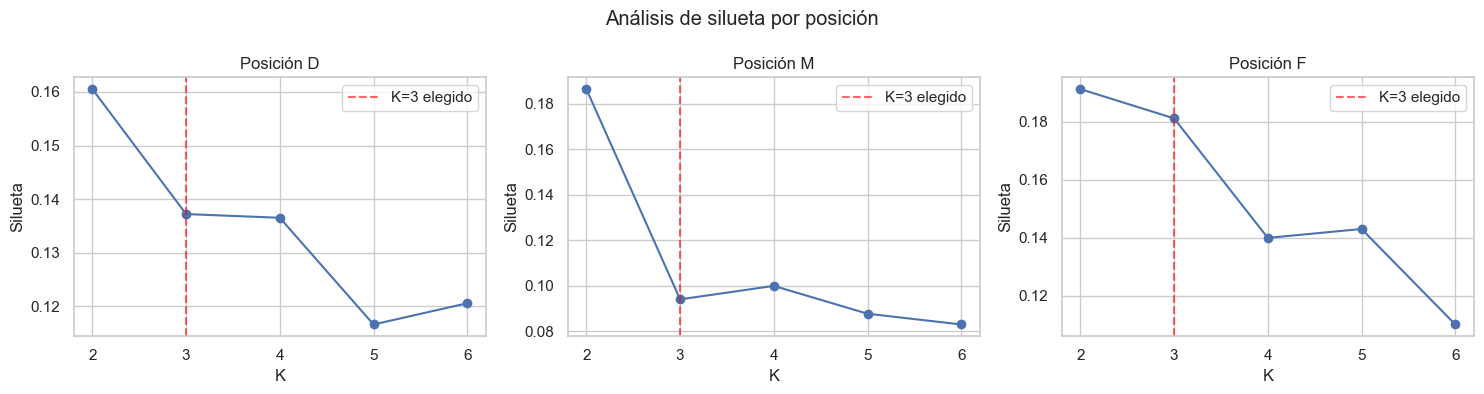

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, pos in zip(axes, ['D','M','F']):
    sub = of[of['position']==pos]
    X = sub[PCS].values
    ks, sils = range(2,7), []
    for k in ks:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        lab = km.fit_predict(X)
        sils.append(silhouette_score(X, lab, sample_size=min(3000,len(X)), random_state=42))
    ax.plot(list(ks), sils, 'o-')
    ax.axvline(3, color='red', ls='--', alpha=0.6, label='K=3 elegido')
    ax.set_title(f'Posición {pos}'); ax.set_xlabel('K'); ax.set_ylabel('Silueta'); ax.legend()
plt.suptitle('Análisis de silueta por posición')
plt.tight_layout(); plt.show()

**Conclusión.** La silueta favorece K=2, pero produce una división demasiado gruesa. Se elige **K=3** porque los subtipos resultantes son claramente interpretables en términos futbolísticos (ver sección 4), un criterio tan válido como la métrica de silueta cuando los datos forman un continuo sin grupos nítidos.

## 3. Clustering K=3 por posición

In [3]:
K = 3
of['arquetipo_id'] = -1
modelos_km = {}
for pos in ['D','M','F']:
    mask = of['position']==pos
    X = of.loc[mask, PCS].values
    km = KMeans(n_clusters=K, random_state=42, n_init=10)
    of.loc[mask, 'arquetipo_id'] = km.fit_predict(X)
    modelos_km[pos] = km
    print(f'Posición {pos}: {mask.sum()} jugadores → {K} arquetipos')

Posición D: 5162 jugadores → 3 arquetipos
Posición M: 3316 jugadores → 3 arquetipos
Posición F: 4685 jugadores → 3 arquetipos


## 4. Caracterización de los arquetipos

Se describen los subtipos con estadísticas interpretables (por 90 minutos), recuperadas de
`master_filtered.csv`, y su salario medio.

In [4]:
filt = pd.read_csv(FILT_PATH, dtype={'season': str})
stats = ['goals','assists','keyPasses','tackles','interceptions',
         'successfulDribbles','aerialDuelsWon','minutesPlayed']
stats = [s for s in stats if s in filt.columns]
m = of.merge(filt[['player_id','season']+stats], on=['player_id','season'], how='left')

def perfil(pos):
    sub = m[m['position']==pos]
    out = sub.groupby('arquetipo_id').apply(lambda d: pd.Series({
        'n': len(d),
        'goals/90':  (d['goals']/d['minutesPlayed']*90).mean(),
        'assists/90':(d['assists']/d['minutesPlayed']*90).mean(),
        'keyPass/90':(d['keyPasses']/d['minutesPlayed']*90).mean(),
        'tackles/90':(d['tackles']/d['minutesPlayed']*90).mean(),
        'interc/90': (d['interceptions']/d['minutesPlayed']*90).mean(),
        'dribbles/90':(d['successfulDribbles']/d['minutesPlayed']*90).mean(),
        'aerial/90': (d['aerialDuelsWon']/d['minutesPlayed']*90).mean(),
        'salario_M': d['gross_annual_eur'].mean()/1e6,
    }))
    return out.round(2)

for pos, nombre in [('F','DELANTEROS'),('M','MEDIOCENTROS'),('D','DEFENSAS')]:
    print(f'\n=== {nombre} ===')
    display(perfil(pos))


=== DELANTEROS ===


,n,goals/90,assists/90,keyPass/90,tackles/90,interc/90,dribbles/90,aerial/90,salario_M
arquetipo_id,,,,,,,,,
0,1533.0,0.37,0.10,0.92,0.78,0.26,0.81,2.60,2.44
1,2495.0,0.17,0.14,1.40,1.41,0.57,1.49,0.77,2.08
2,657.0,0.45,0.26,2.01,1.12,0.43,1.63,0.69,7.13



=== MEDIOCENTROS ===


,n,goals/90,assists/90,keyPass/90,tackles/90,interc/90,dribbles/90,aerial/90,salario_M
arquetipo_id,,,,,,,,,
0,1114.0,0.11,0.10,1.03,1.83,0.86,0.83,1.11,1.72
1,579.0,0.15,0.16,1.62,1.91,0.98,0.93,0.84,5.14
2,1623.0,0.04,0.05,0.67,2.24,1.27,0.69,1.20,2.03



=== DEFENSAS ===


,n,goals/90,assists/90,keyPass/90,tackles/90,interc/90,dribbles/90,aerial/90,salario_M
arquetipo_id,,,,,,,,,
0,964.0,0.08,0.04,0.36,1.52,1.34,0.30,2.38,3.48
1,2240.0,0.04,0.09,0.91,2.03,1.13,0.75,1.04,1.82
2,1958.0,0.03,0.02,0.22,1.46,1.26,0.22,2.04,1.92


## 5. Interpretación: nombres de los arquetipos

A partir de los perfiles, se asigna un nombre futbolístico a cada subtipo. **Nota:** los identificadores
numéricos de cluster (`arquetipo_id`) no son deterministas entre ejecuciones; la interpretación debe
hacerse leyendo el perfil de stats de cada grupo, no su número.

In [5]:
# Asignación interpretativa basada en el perfil de stats (leer la tabla de la sección 4).
# Se construye un nombre legible identificando el arquetipo por su característica dominante.
def nombrar_arquetipos(pos):
    sub = m[m['position']==pos]
    nombres = {}
    for aid in sorted(sub['arquetipo_id'].unique()):
        d = sub[sub['arquetipo_id']==aid]
        g  = (d['goals']/d['minutesPlayed']*90).mean()
        kp = (d['keyPasses']/d['minutesPlayed']*90).mean()
        dr = (d['successfulDribbles']/d['minutesPlayed']*90).mean()
        ae = (d['aerialDuelsWon']/d['minutesPlayed']*90).mean()
        ta = (d['tackles']/d['minutesPlayed']*90).mean()
        ia = (d['interceptions']/d['minutesPlayed']*90).mean()
        if pos=='F':
            if g>0.30 and ae>1.5:   nombres[aid]='Killer de área'
            elif kp>1.7 or g>0.40:  nombres[aid]='Atacante total / creador'
            else:                   nombres[aid]='Extremo asociativo'
        elif pos=='M':
            if kp>1.4:              nombres[aid]='Organizador creativo'
            elif ia>1.1:            nombres[aid]='Pivote defensivo'
            else:                   nombres[aid]='Box-to-box'
        else:  # D
            if dr>0.6 and kp>0.7:   nombres[aid]='Lateral / carrilero ofensivo'
            elif ae>2.2:            nombres[aid]='Central dominante aéreo'
            else:                   nombres[aid]='Central de marca'
    return nombres

of['arquetipo'] = ''
for pos in ['D','M','F']:
    nombres = nombrar_arquetipos(pos)
    for aid, nom in nombres.items():
        of.loc[(of['position']==pos)&(of['arquetipo_id']==aid),'arquetipo'] = nom
    print(f'{pos}: {list(nombres.values())}')

print('\n=== Salario medio por arquetipo ===')
resumen = (of.groupby(['position','arquetipo'])
             .agg(n=('player_id','size'), salario_M=('gross_annual_eur', lambda x: x.mean()/1e6))
             .round(2).sort_values(['position','salario_M'], ascending=[True,False]))
display(resumen)

D: ['Central dominante aéreo', 'Lateral / carrilero ofensivo', 'Central de marca']
M: ['Box-to-box', 'Organizador creativo', 'Pivote defensivo']
F: ['Killer de área', 'Extremo asociativo', 'Atacante total / creador']

=== Salario medio por arquetipo ===


n  salario_M
position arquetipo                                    
D        Central dominante aéreo        964       3.48
         Central de marca              1958       1.92
         Lateral / carrilero ofensivo  2240       1.82
F        Atacante total / creador       657       7.13
         Killer de área                1533       2.44
         Extremo asociativo            2495       2.08
M        Organizador creativo           579       5.14
         Pivote defensivo              1623       2.03
         Box-to-box                    1114       1.72

## 6. Visualización con UMAP

UMAP proyecta los vectores PCA a 2D preservando mejor que PCA la estructura local (relaciones no
lineales). Permite visualizar los arquetipos como regiones del espacio de estilo.

UMAP no disponible (No module named 'umap'); se usa PCA 2D como alternativa.


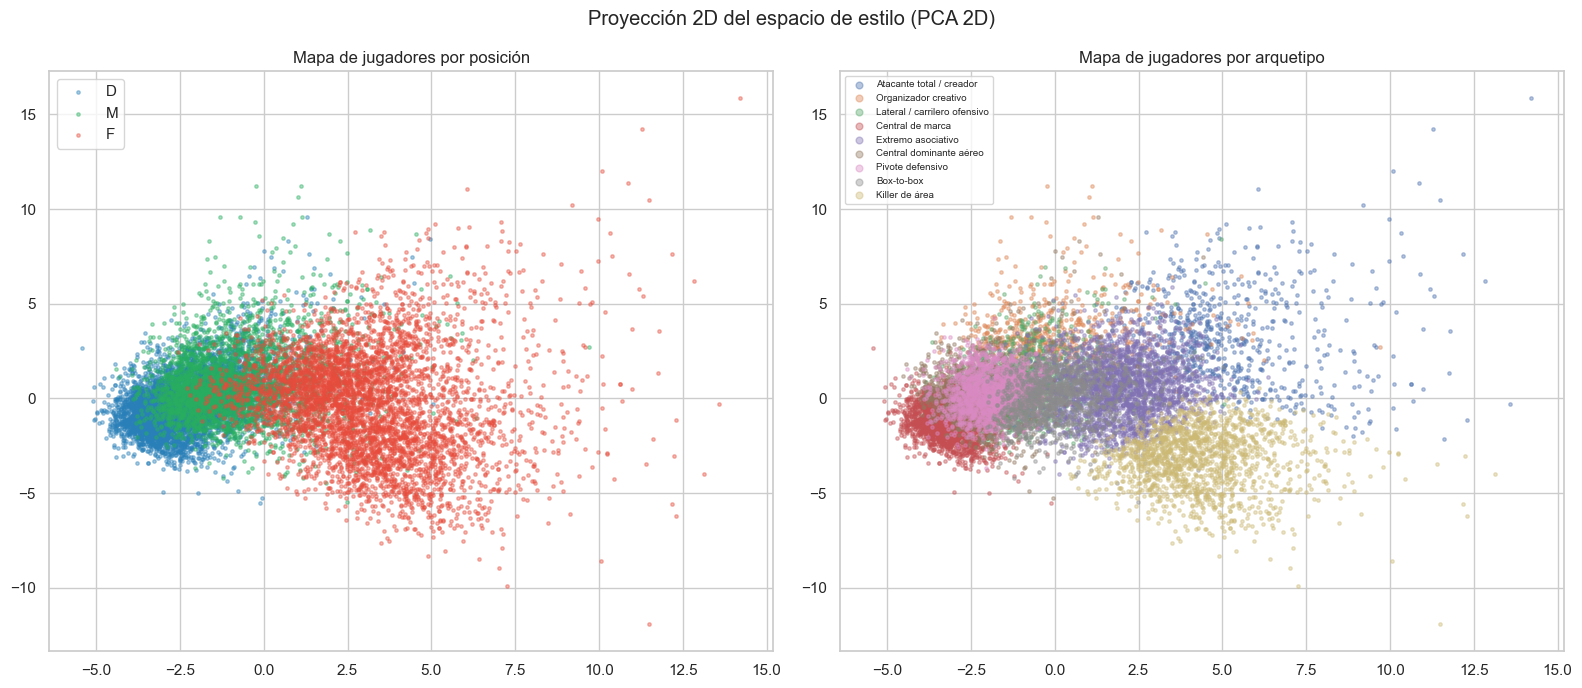

In [6]:
try:
    import umap
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    emb = reducer.fit_transform(of[PCS].values)
    of['umap_x'], of['umap_y'] = emb[:,0], emb[:,1]
    umap_ok = True
except Exception as e:
    print(f'UMAP no disponible ({e}); se usa PCA 2D como alternativa.')
    of['umap_x'], of['umap_y'] = of['PC1'], of['PC2']
    umap_ok = False

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
# Coloreado por posición
for pos, color in zip(['D','M','F'], ['#2980b9','#27ae60','#e74c3c']):
    s = of[of['position']==pos]
    axes[0].scatter(s['umap_x'], s['umap_y'], s=6, alpha=0.4, label=pos, color=color)
axes[0].set_title('Mapa de jugadores por posición'); axes[0].legend()

# Coloreado por arquetipo
for arq in of['arquetipo'].unique():
    s = of[of['arquetipo']==arq]
    axes[1].scatter(s['umap_x'], s['umap_y'], s=6, alpha=0.4, label=arq)
axes[1].set_title('Mapa de jugadores por arquetipo')
axes[1].legend(fontsize=7, markerscale=2)
metodo = 'UMAP' if umap_ok else 'PCA 2D'
plt.suptitle(f'Proyección 2D del espacio de estilo ({metodo})')
plt.tight_layout(); plt.show()

## 7.5 Exportación del artefacto para la plataforma

Se exporta la asignación de arquetipo de cada jugador-temporada a `arquetipos.csv`, para que la
plataforma Streamlit muestre el arquetipo en la ficha de cada jugador sin recalcular el clustering.
Los porteros, que no se segmentan en este análisis, reciben la etiqueta genérica "Portero".

In [7]:
# Construir el artefacto: player_id, season, position, arquetipo
arquetipos_export = of[['player_id', 'season', 'position', 'arquetipo']].copy()

# Los porteros no entran en el clustering (análisis de jugadores de campo): etiqueta genérica
# Se añaden desde el dataset de porteros para que la plataforma tenga a todos los jugadores
gk_export = gk[['player_id', 'season', 'position']].copy()
gk_export['arquetipo'] = 'Portero'

arquetipos_export = pd.concat([arquetipos_export, gk_export], ignore_index=True)

OUT_PATH = ROOT / 'data' / 'modeling' / 'similarity' / 'arquetipos.csv'
arquetipos_export.to_csv(OUT_PATH, index=False)
print(f'Exportados {len(arquetipos_export):,} arquetipos a: {OUT_PATH}')
arquetipos_export['arquetipo'].value_counts()

Exportados 14,202 arquetipos a: d:\USER\Desktop\TFM\data\modeling\similarity\arquetipos.csv


arquetipo
Extremo asociativo              2495
Lateral / carrilero ofensivo    2240
Central de marca                1958
Pivote defensivo                1623
Killer de área                  1533
Box-to-box                      1114
Portero                         1039
Central dominante aéreo          964
Atacante total / creador         657
Organizador creativo             579
Name: count, dtype: int64

## 7. Ejemplos: ¿a qué arquetipo pertenecen jugadores conocidos?

In [8]:
ejemplos_id = {
    'Robert Lewandowski': 41789, 'Vinicius Júnior': 868812, 'Pedri': 992587,
    'Rodri': 827606, 'William Saliba': 941168, 'Luka Modrić': 15466,
}
print('Arquetipo asignado (temporada más reciente):\n')
for nombre, pid in ejemplos_id.items():
    r = of[of['player_id']==pid].sort_values('season')
    if len(r):
        r = r.iloc[-1]
        print(f"  {nombre:<22} → {r['arquetipo']} ({r['position']})")

Arquetipo asignado (temporada más reciente):

  Robert Lewandowski     → Killer de área (F)
  Vinicius Júnior        → Atacante total / creador (F)
  Pedri                  → Organizador creativo (M)
  Rodri                  → Organizador creativo (M)
  William Saliba         → Central de marca (D)
  Luka Modrić            → Organizador creativo (M)


## 8. Conclusiones

### Análisis realizado
Clustering K-means (K=3) por posición sobre los vectores PCA, identificando subtipos de jugador
interpretables: tipos de delantero (killer de área, atacante total, extremo asociativo), de
mediocentro (organizador, pivote, box-to-box) y de defensa (central aéreo, central de marca, lateral
ofensivo).

### Hallazgos
- Los arquetipos **más ofensivos y creativos concentran los salarios más altos** dentro de cada
  posición (p. ej. el "atacante total" y el "organizador creativo"), confirmando que el mercado premia
  la producción ofensiva y la creación de juego.
- Se verificó que un clustering global se limita a reproducir la posición; la segmentación por posición
  es la que aporta conocimiento nuevo.

### Aportación metodológica
Este análisis incorpora un algoritmo de aprendizaje no supervisado que **aprende un modelo** (los
centroides), complementando el PCA (reducción) y la búsqueda de vecinos (recuperación). En conjunto, el
TFM emplea tres técnicas no supervisadas con propósitos distintos: PCA para la representación, K-means
para la tipología, y búsqueda de vecinos para la recomendación.

### Conexión con la plataforma
El arquetipo de cada jugador puede mostrarse en la plataforma como una etiqueta descriptiva
("organizador creativo"), enriqueciendo el perfil junto a la similitud y el salario.